In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

# Statistical models
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Machine learning
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit

In [38]:
try:
    import torch
    import torch.nn as nn
    TORCH_AVAILABLE = True
except ImportError:
    TORCH_AVAILABLE = False
    print("PyTorch not available — LSTM section will be skipped.")

plt.style.use("seaborn-v0_8-whitegrid")
COLORS = ["#2E86AB", "#A23B72", "#F18F01", "#C73E1D", "#3B1F2B"]
SEED = 42
np.random.seed(SEED)


In [39]:
def load_and_merge_data(train_path="train.csv", stores_path="stores.csv", features_path="features.csv"):
    """
    Implements the merging logic found in demand_forecast.ipynb:
    - Loads Train, Stores, and Features
    - Drops redundant 'IsHoliday' from features to avoid merge duplication
    - Left-merges on hierarchical keys
    """
    print("--- Loading and Merging Datasets ---")
    try:
        # Load datasets as per notebook specifications
        train = pd.read_csv(train_path, parse_dates=['Date'])
        stores = pd.read_csv(stores_path)
        features = pd.read_csv(features_path, parse_dates=['Date']).drop(columns=['IsHoliday'], errors='ignore')
        
        # Merging logic from cell [24] of notebook
        dataset = train.merge(stores, how='left').merge(features, how='left')
        
        # Clean column names for consistency
        dataset.columns = [c.lower().replace(" ", "_") for c in dataset.columns]
        dataset = dataset.sort_values(["store", "dept", "date"]).reset_index(drop=True)
        
        print(f"Dataset Merged: {dataset.shape[0]:,} rows | {dataset['store'].nunique()} stores")
        return dataset
    except Exception as e:
        print(f"Error loading files: {e}")
        return None
    
data = load_and_merge_data()

--- Loading and Merging Datasets ---
Dataset Merged: 421,570 rows | 45 stores


In [ ]:
def engineer_features(df):
    df = df.copy()
    
    # Calendar features
    df["week_of_year"] = df["date"].dt.isocalendar().week.astype(int)
    df["month"] = df["date"].dt.month
    df["year"] = df["date"].dt.year
    df["quarter"] = df["date"].dt.quarter
    df["year"] = df["date"].dt.year


    # Lag features (per store-department)
    for lag in [1, 2, 4, 8, 13, 26, 52]:
        df[f"sales_lag_{lag}w"] = (
            df.groupby(["store","dept"])["weekly_sales"].shift(lag))

    # Rolling statistics (prevent data leakage: use shift(1) before rolling)
    for window in [4, 8, 13]:
        shifted = df.groupby(["store","dept"])["weekly_sales"].shift(1)
        df[f"roll_mean_{window}w"] = (
            shifted.groupby([df["store"], df["dept"]])
            .transform(lambda x: x.rolling(window, min_periods=1).mean())
        )
        df[f"roll_std_{window}w"]  = (
            shifted.groupby([df["store"], df["dept"]])
            .transform(lambda x: x.rolling(window, min_periods=1).std())
        )

    # Markdown total (fill missing with 0)
    markdown_cols = [c for c in df.columns if "markdown" in c.lower()]
    if markdown_cols:
        df["total_markdown"] = df[markdown_cols].fillna(0).sum(axis=1)
        df["markdown_holiday_interaction"] = df["total_markdown"] * df["isholiday"].astype(int)

    # Trend index per series
    df["time_idx"] = df.groupby(["store","dept"]).cumcount()

    # Encode store type if present
    if "type" in df.columns:
        le = LabelEncoder()
        df["store_type_enc"] = le.fit_transform(df["type"].astype(str))

    print(f"Features engineered: {df.shape[1]} total columns")
    df = df.fillna(0)
    print(f"Feature Engineering Complete: {df.shape[1]} total features.")
    return df.set_index("date")

engineer_features(data)

Features engineered: 37 total columns
Feature Engineering Complete: 37 total features.


,store,dept,weekly_sales,isholiday,type,size,temperature,fuel_price,markdown1,markdown2,...,roll_mean_4w,roll_std_4w,roll_mean_8w,roll_std_8w,roll_mean_13w,roll_std_13w,total_markdown,markdown_holiday_interaction,time_idx,store_type_enc
date,,,,,,,,,,,,,,,,,,,,,
2010-02-05,1,1,24924.50,False,A,151315,42.31,2.572,0.00,0.00,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00,0.0,0,0
2010-02-12,1,1,46039.49,True,A,151315,38.51,2.548,0.00,0.00,...,24924.500000,0.000000,24924.500000,0.000000,24924.500000,0.000000,0.00,0.0,1,0
2010-02-19,1,1,41595.55,False,A,151315,39.93,2.514,0.00,0.00,...,35481.995000,14930.552614,35481.995000,14930.552614,35481.995000,14930.552614,0.00,0.0,2,0
2010-02-26,1,1,19403.54,False,A,151315,46.63,2.561,0.00,0.00,...,37519.846667,11131.900957,37519.846667,11131.900957,37519.846667,11131.900957,0.00,0.0,3,0
2010-03-05,1,1,21827.90,False,A,151315,46.50,2.625,0.00,0.00,...,32990.770000,12832.106391,32990.770000,12832.106391,32990.770000,12832.106391,0.00,0.0,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2012-09-28,45,98,508.37,False,B,118221,64.88,3.997,4556.61,20.64,...,442.935000,122.132155,491.406250,128.931568,575.350769,154.681368,9468.01,0.0,130,1
2012-10-05,45,98,628.10,False,B,118221,64.89,3.985,5046.74,0.00,...,483.517500,104.966869,490.395000,128.738573,561.339231,151.598752,9659.00,0.0,131,1
2012-10-12,45,98,1061.02,False,B,118221,54.47,4.000,1956.28,0.00,...,552.432500,76.984436,477.971250,105.240658,558.912308,150.139269,6554.03,0.0,132,1


In [ ]:
data.isna().sum()/len(data)
data.dropna(inplace=True) 

### Exploratory Data Analysis

In [ ]:
x

NameError: name 'x' is not defined

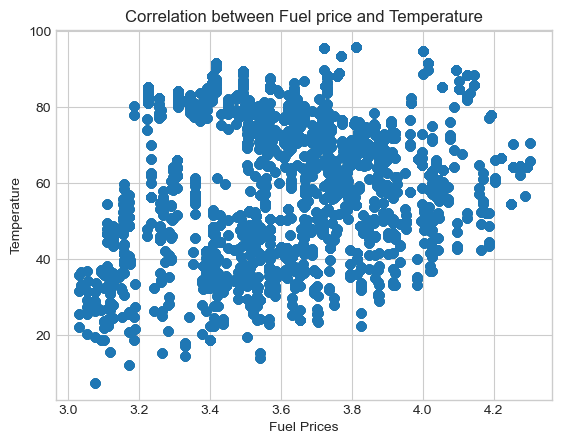

In [ ]:
# Correlation between Fuel price and Temperature
plt.scatter(data['fuel_price'],data['temperature'])
plt.xlabel('Fuel Prices')
plt.ylabel('Temperature')
plt.title('Correlation between Fuel price and Temperature')
plt.show()

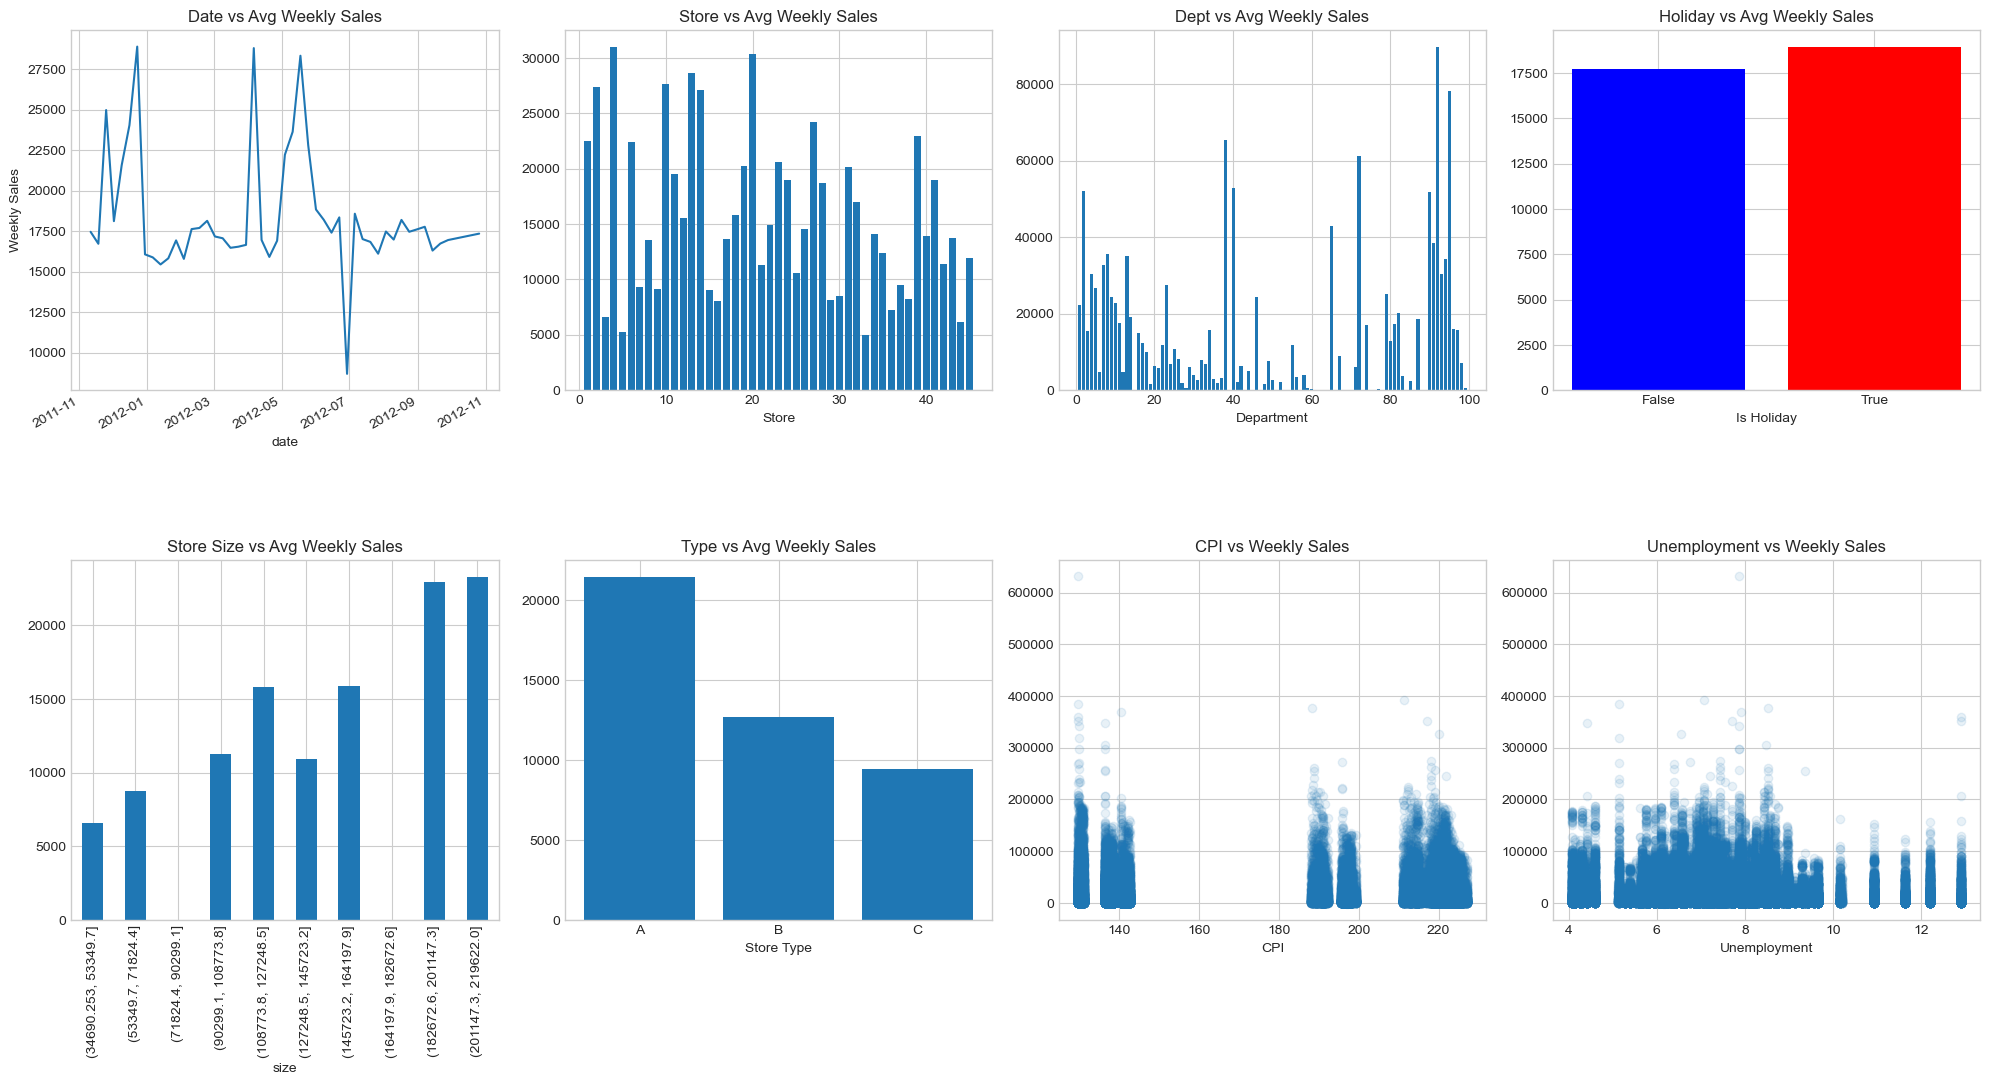

In [ ]:
plt.figure(figsize=(20, 20))
# 1. Date vs Weekly Sales
plt.subplot(4, 4, 1)
data.groupby('date')['weekly_sales'].mean().plot()
plt.title('Date vs Avg Weekly Sales')
plt.ylabel('Weekly Sales')

# 2. Store vs Weekly Sales
plt.subplot(4, 4, 2)
store_sales = data.groupby('store')['weekly_sales'].mean()
plt.bar(store_sales.index, store_sales.values)
plt.xlabel('Store')
plt.title('Store vs Avg Weekly Sales')

# 3. Department vs Weekly Sales 
plt.subplot(4, 4, 3)
dept_sales = data.groupby('dept')['weekly_sales'].mean()
plt.bar(dept_sales.index, dept_sales.values)
plt.xlabel('Department')
plt.title('Dept vs Avg Weekly Sales')

# 4. Holidays vs Weekly Sales
plt.subplot(4, 4, 4)
holiday_sales = data.groupby('isholiday')['weekly_sales'].mean()
plt.bar(holiday_sales.index.astype(str), holiday_sales.values, color=['blue', 'red'])
plt.xlabel('Is Holiday')
plt.title('Holiday vs Avg Weekly Sales')

# 5. Size vs Weekly Sales 
plt.subplot(4, 4, 5)
# Using a scatter or hexbin is often better for size, but sticking to bar/agg for consistency
size_bins = pd.cut(data['size'], bins=10)
data.groupby(size_bins)['weekly_sales'].mean().plot(kind='bar')
plt.title('Store Size vs Avg Weekly Sales')

# 6. Type vs Weekly Sales
plt.subplot(4, 4, 6)
type_sales = data.groupby('type')['weekly_sales'].mean()
plt.bar(type_sales.index, type_sales.values)
plt.xlabel('Store Type')
plt.title('Type vs Avg Weekly Sales')

# 7. CPI vs Weekly Sales
plt.subplot(4, 4, 7)
plt.scatter(data['cpi'], data['weekly_sales'], alpha=0.1)
plt.xlabel('CPI')
plt.title('CPI vs Weekly Sales')

# 8. Unemployment vs Weekly Sales 
plt.subplot(4, 4, 8)
plt.scatter(data['unemployment'], data['weekly_sales'], alpha=0.1)
plt.xlabel('Unemployment')
plt.title('Unemployment vs Weekly Sales')

plt.tight_layout()
plt.show()

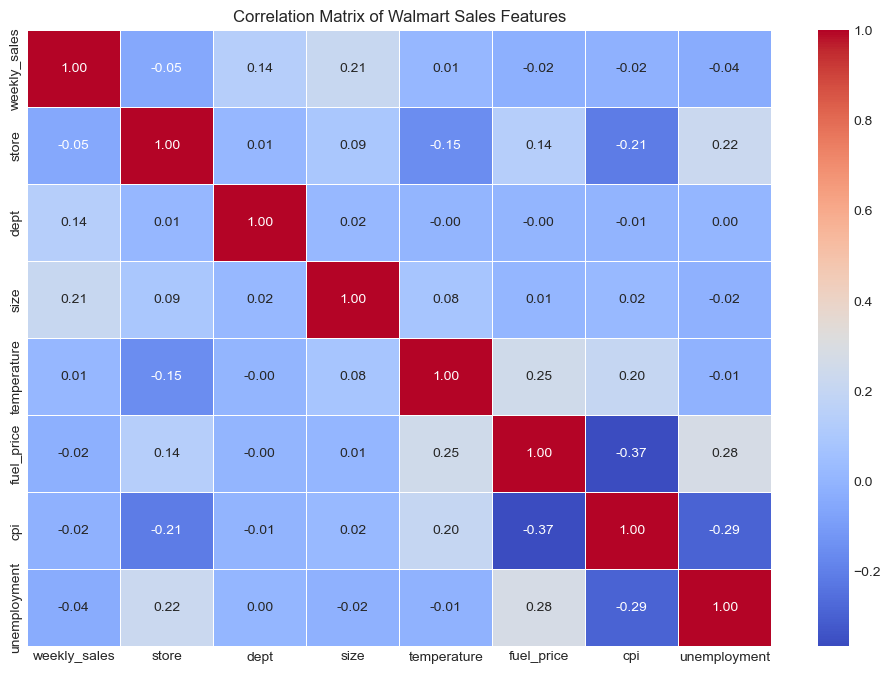

In [ ]:
# numerical columns for correlation
numerical_cols = ['weekly_sales', 'store', 'dept','size','temperature', 'fuel_price', 'cpi', 'unemployment']
corr_matrix = data[numerical_cols].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Walmart Sales Features')
plt.show()

Maximum Sales: 630,999
  - Occurred in Store: 10
  - In Department: 72
  - On Date: 2011-11-25 00:00:00
	
Minimum Sales: -1,699
  - Occurred in Store: 16
  - In Department: 47
  - On Date: 2012-03-09 00:00:00


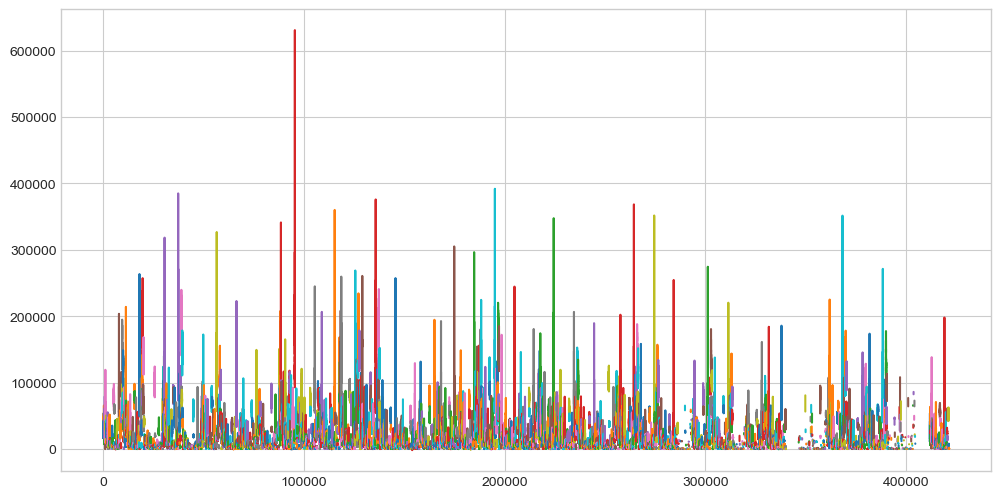

In [ ]:
data.groupby(["store", "dept"])["weekly_sales"].plot(legend=False, figsize=(12, 6))
# To Find the row with the global Minimum & Maximum sales
max_idx = data["weekly_sales"].idxmax()
max_row = data.loc[max_idx]
min_idx = data["weekly_sales"].idxmin()
min_row = data.loc[min_idx]

print(f"Maximum Sales: {max_row['weekly_sales']:,.0f}")
print(f"  - Occurred in Store: {max_row['store']}")
print(f"  - In Department: {max_row['dept']}")
print(f"  - On Date: {max_row['date']}")
print('\t')
print(f"Minimum Sales: {min_row['weekly_sales']:,.0f}")
print(f"  - Occurred in Store: {min_row['store']}")
print(f"  - In Department: {min_row['dept']}")
print(f"  - On Date: {min_row['date']}")

In [ ]:
def analyze_time_series(df: pd.DataFrame, store: int = 1, dept: int = 1) -> None:

    series = (df[(df["store"] == store) & (df["dept"] == dept)]
              .set_index("date")["weekly_sales"]
              .dropna()
              .sort_index())

    print("=" * 60)
    print(f"TIME SERIES DIAGNOSTICS — Store {store}, Dept {dept}")
    print("=" * 60)

    # ADF Test
    adf_result = adfuller(series, autolag="AIC")
    print(f"\nAugmented Dickey-Fuller Test:")
    print(f"  ADF Statistic: {adf_result[0]:.4f}")
    print(f"  p-value:       {adf_result[1]:.4f}")
    print(f"  Conclusion:    {'Stationary ✓' if adf_result[1] < 0.05 else 'Non-stationary — differencing required'}")

    # Decomposition
    from statsmodels.tsa.seasonal import seasonal_decompose
    if len(series) >= 104:  # Need 2 full years for period=52
        decomp = seasonal_decompose(series, model="multiplicative", period=52)
        fig, axes = plt.subplots(4, 1, figsize=(14, 10))
        decomp.observed.plot(ax=axes[0], title="Observed", color=COLORS[0])
        decomp.trend.plot(ax=axes[1], title="Trend", color=COLORS[1])
        decomp.seasonal.plot(ax=axes[2], title="Seasonal (Annual)", color=COLORS[2])
        decomp.resid.plot(ax=axes[3], title="Residuals", color=COLORS[3])
        plt.suptitle(f"Time Series Decomposition — Store {store} Dept {dept}", y=1.02)
        plt.tight_layout()
        plt.show()

In [ ]:
analyze_time_series(data)

TIME SERIES DIAGNOSTICS — Store 1, Dept 1

Augmented Dickey-Fuller Test:
  ADF Statistic: -3.3022
  p-value:       0.0148
  Conclusion:    Stationary ✓


In [ ]:
def evaluate_models(df: pd.DataFrame,
                     store: int = 1,
                     dept: int = 1,
                     test_weeks: int = 12) -> pd.DataFrame:
    series_df = (df[(df["store"] == store) & (df["dept"] == dept)]
                 .sort_values("date")
                 .dropna(subset=["weekly_sales"]))

    y = series_df["weekly_sales"].values
    train_y, test_y = y[:-test_weeks], y[-test_weeks:]

    results = []
    import time

    def _metrics(name, pred, actual, elapsed):
        mae   = mean_absolute_error(actual, pred)
        rmse  = np.sqrt(mean_squared_error(actual, pred))
        mape  = np.mean(np.abs((actual - pred) / (actual + 1e-8))) * 100
        smape = np.mean(2 * np.abs(actual - pred) / (np.abs(actual) + np.abs(pred) + 1e-8)) * 100
        results.append({"model": name, "MAE": mae, "RMSE": rmse,
                         "MAPE%": mape, "SMAPE%": smape, "time_sec": elapsed})

    # 1. Naive baseline
    t0 = time.time()
    naive_pred = np.full(test_weeks, train_y[-1])
    _metrics("Naive (Last Value)", naive_pred, test_y, time.time() - t0)

    # 2. Seasonal Naive (same week last year — strong baseline for weekly retail data)
    t0 = time.time()
    if len(train_y) >= 52:
        snaive_pred = train_y[-52: -52 + test_weeks] if len(train_y) >= 52 + test_weeks else train_y[-test_weeks:]
    else:
        snaive_pred = naive_pred
    _metrics("Seasonal Naive (52w)", snaive_pred, test_y, time.time() - t0)

    # 3. SARIMA
    t0 = time.time()
    try:
        sarima = SARIMAX(train_y, order=(1,1,1), seasonal_order=(1,1,1,52),
                          enforce_stationarity=False, enforce_invertibility=False)
        sarima_fit = sarima.fit(disp=False)
        sarima_pred = sarima_fit.forecast(steps=test_weeks)
        _metrics("SARIMA(1,1,1)(1,1,1,52)", np.array(sarima_pred), test_y, time.time() - t0)
    except Exception as e:
        print(f"  SARIMA failed: {e} — skipping")

    # 4. XGBoost with lag features
    t0 = time.time()
    try:
        from xgboost import XGBRegressor

        def make_features_array(y_arr, n_lags=13):
            X, Y = [], []
            for i in range(n_lags, len(y_arr)):
                X.append(y_arr[i-n_lags:i][::-1])
                Y.append(y_arr[i])
            return np.array(X), np.array(Y)

        n_lags = min(13, len(train_y) - 1)
        X_tr, Y_tr = make_features_array(train_y, n_lags)
        xgb = XGBRegressor(n_estimators=500, learning_rate=0.05,
                            max_depth=6, subsample=0.8,
                            colsample_bytree=0.8, random_state=SEED)
        xgb.fit(X_tr, Y_tr, verbose=False)

        # Recursive multi-step forecast
        history = list(train_y)
        xgb_preds = []
        for _ in range(test_weeks):
            x = np.array(history[-n_lags:][::-1]).reshape(1, -1)
            p = xgb.predict(x)[0]
            xgb_preds.append(p)
            history.append(p)
        _metrics("XGBoost (lag features)", np.array(xgb_preds), test_y, time.time() - t0)
    except ImportError:
        print("  XGBoost not installed — run: pip install xgboost")

    # 5. LSTM (if torch available)
    if TORCH_AVAILABLE:
        t0 = time.time()
        lstm_preds = _lstm_forecast(train_y, test_weeks)
        _metrics("LSTM (PyTorch)", lstm_preds, test_y, time.time() - t0)

    results_df = pd.DataFrame(results)
    print("\n" + "=" * 60)
    print("MODEL COMPARISON RESULTS")
    print("=" * 60)
    print(results_df.round(2).to_string(index=False))

    # Winner
    best = results_df.loc[results_df["SMAPE%"].idxmin(), "model"]
    print(f"\n  Best model (lowest SMAPE): {best}")

    # Model selection framework
    print("\n  MODEL SELECTION GUIDE:")
    print("  ├─ Short horizon (1-4 weeks), limited data   → Seasonal Naive / SARIMA")
    print("  ├─ Medium horizon (4-12 weeks), rich features → XGBoost")
    print("  └─ Long horizon (12+ weeks), large dataset   → LSTM / N-BEATS")

    # Plot forecasts
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.plot(range(len(test_y)), test_y, "k-o", lw=2, label="Actual", markersize=5)
    for i, row in enumerate(results):
        ax.plot(row.get("_pred", []), "--", color=COLORS[i % len(COLORS)],
                lw=1.5, label=row["model"], alpha=0.8)
    ax.set_title(f"Forecast Comparison — Store {store} Dept {dept} ({test_weeks}-Week Horizon)",
                 fontsize=13)
    ax.set_xlabel("Week")
    ax.set_ylabel("Weekly Sales (£)")
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.close()
    plt.show()

    return results_df


def _lstm_forecast(train_y: np.ndarray, steps: int,
                   seq_len: int = 13, epochs: int = 50) -> np.ndarray:
    """LSTM-based recursive multi-step forecasting."""
    import torch
    import torch.nn as nn

    # Normalize
    mu, sigma = train_y.mean(), train_y.std() + 1e-8
    y_norm = (train_y - mu) / sigma

    # Build sequences
    X, Y = [], []
    for i in range(seq_len, len(y_norm)):
        X.append(y_norm[i-seq_len:i])
        Y.append(y_norm[i])
    X_t = torch.FloatTensor(X).unsqueeze(-1)
    Y_t = torch.FloatTensor(Y)

    class LSTMForecaster(nn.Module):
        def __init__(self):
            super().__init__()
            self.lstm = nn.LSTM(1, 64, num_layers=2, batch_first=True, dropout=0.2)
            self.fc   = nn.Linear(64, 1)
        def forward(self, x):
            out, _ = self.lstm(x)
            return self.fc(out[:, -1, :]).squeeze(-1)

    model = LSTMForecaster()
    opt   = torch.optim.Adam(model.parameters(), lr=0.001)
    loss_fn = nn.MSELoss()

    for epoch in range(epochs):
        model.train()
        opt.zero_grad()
        pred = model(X_t)
        loss = loss_fn(pred, Y_t)
        loss.backward()
        opt.step()

    # Recursive forecast
    model.eval()
    history = list(y_norm)
    preds_norm = []
    with torch.no_grad():
        for _ in range(steps):
            seq = torch.FloatTensor(history[-seq_len:]).unsqueeze(0).unsqueeze(-1)
            p   = model(seq).item()
            preds_norm.append(p)
            history.append(p)

    return np.array(preds_norm) * sigma + mu


In [ ]:
evaluate_models(data)


MODEL COMPARISON RESULTS
                  model     MAE    RMSE  MAPE%  SMAPE%  time_sec
     Naive (Last Value) 1951.47 3464.90   8.98   10.09      0.00
   Seasonal Naive (52w) 1951.47 3464.90   8.98   10.09      0.00
SARIMA(1,1,1)(1,1,1,52) 1951.47 3464.90   8.98   10.09      0.32
 XGBoost (lag features) 7135.38 9211.05  41.04   32.09      2.11
         LSTM (PyTorch) 4826.94 6026.16  24.53   29.18      3.11

  Best model (lowest SMAPE): Naive (Last Value)

  MODEL SELECTION GUIDE:
  ├─ Short horizon (1-4 weeks), limited data   → Seasonal Naive / SARIMA
  ├─ Medium horizon (4-12 weeks), rich features → XGBoost
  └─ Long horizon (12+ weeks), large dataset   → LSTM / N-BEATS


,model,MAE,RMSE,MAPE%,SMAPE%,time_sec
0,Naive (Last Value),1951.473333,3464.898432,8.980665,10.090472,0.000008
1,Seasonal Naive (52w),1951.473333,3464.898432,8.980665,10.090472,0.000003
2,"SARIMA(1,1,1)(1,1,1,52)",1951.473333,3464.898432,8.980665,10.090472,0.323004
3,XGBoost (lag features),7135.380358,9211.052681,41.044607,32.088805,2.107445
4,LSTM (PyTorch),4826.944907,6026.162757,24.529864,29.179945,3.112754


In [ ]:
def hierarchical_accuracy_analysis(df: pd.DataFrame) -> pd.DataFrame:
    print("=" * 60)
    print("HIERARCHICAL FORECASTING ACCURACY DEGRADATION")
    print("=" * 60)

    levels = [
        ("Chain (All)", lambda d: d.groupby("date")["weekly_sales"].sum().reset_index()),
        ("Store",       lambda d: d.groupby(["store","date"])["weekly_sales"].sum().reset_index()),
        ("Dept",        lambda d: d.groupby(["dept","date"])["weekly_sales"].sum().reset_index()),
        ("StoreDept",  lambda d: d.groupby(["store","dept","date"])["weekly_sales"].sum().reset_index()),
    ]

    test_weeks = 8
    rows = []

    for level_name, agg_fn in levels:
        agg_df = agg_fn(df)
        group_cols = [c for c in agg_df.columns if c not in ["date","weekly_sales"]]
        smapes = []

        for keys, grp in agg_df.groupby(group_cols) if group_cols else [((), agg_df)]:
            grp = grp.sort_values("date")
            y = grp["weekly_sales"].values
            if len(y) <= test_weeks + 52:
                continue
            train_y, test_y = y[:-test_weeks], y[-test_weeks:]
            # Seasonal naive baseline
            pred = train_y[-52:-52+test_weeks] if len(train_y) >= 52 + test_weeks else np.full(test_weeks, train_y[-1])
            smape = np.mean(2 * np.abs(test_y - pred) / (np.abs(test_y) + np.abs(pred) + 1e-8)) * 100
            smapes.append(smape)

        if smapes:
            rows.append({
                "level": level_name,
                "n_series": len(smapes),
                "avg_smape%": np.mean(smapes),
                "median_smape%": np.median(smapes),
                "p90_smape%": np.percentile(smapes, 90),
            })

    result = pd.DataFrame(rows)
    print(result.round(2).to_string(index=False))
    print("\n  Insight: SMAPE typically doubles or triples at dept vs chain level.")
    print("  This degradation is the core challenge of retail forecasting at scale.")
    return result
hierarchical_accuracy_analysis(data)

HIERARCHICAL FORECASTING ACCURACY DEGRADATION
Empty DataFrame
Columns: []
Index: []

  Insight: SMAPE typically doubles or triples at dept vs chain level.
  This degradation is the core challenge of retail forecasting at scale.


""


FORECAST UNCERTAINTY (Conformal Prediction Intervals)


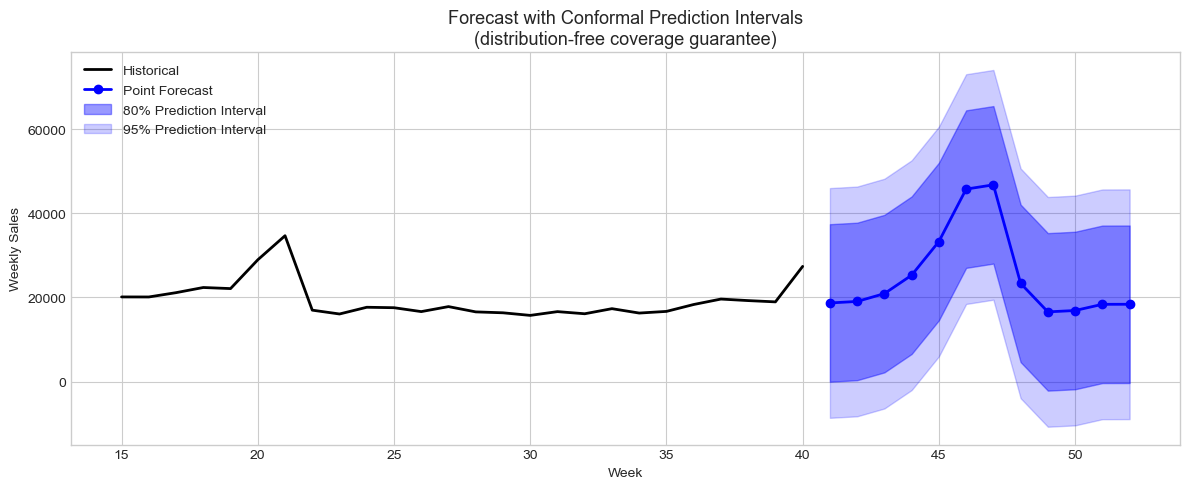


  80% PI half-width: ±18,735
  95% PI half-width: ±27,326


{'point_forecast': array([18689.54, 19050.66, 20911.25, 25293.49, 33305.92, 45773.03,
        46788.75, 23350.88, 16567.69, 16894.4 , 18365.1 , 18378.16]),
 'lower_80': array([  -45.51,   315.61,  2176.2 ,  6558.44, 14570.87, 27037.98,
        28053.7 ,  4615.83, -2167.36, -1840.65,  -369.95,  -356.89]),
 'upper_80': array([37424.59, 37785.71, 39646.3 , 44028.54, 52040.97, 64508.08,
        65523.8 , 42085.93, 35302.74, 35629.45, 37100.15, 37113.21]),
 'lower_95': array([ -8635.9615,  -8274.8415,  -6414.2515,  -2032.0115,   5980.4185,
         18447.5285,  19463.2485,  -3974.6215, -10757.8115, -10431.1015,
         -8960.4015,  -8947.3415]),
 'upper_95': array([46015.0415, 46376.1615, 48236.7515, 52618.9915, 60631.4215,
        73098.5315, 74114.2515, 50676.3815, 43893.1915, 44219.9015,
        45690.6015, 45703.6615])}

In [ ]:

def forecast_with_uncertainty(train_y: np.ndarray, steps: int = 12) -> dict:
    print("=" * 60)
    print("FORECAST UNCERTAINTY (Conformal Prediction Intervals)")
    print("=" * 60)

    # Split: use last 20% as calibration set
    n_cal = max(10, len(train_y) // 5)
    train_fit, cal_y = train_y[:-n_cal], train_y[-n_cal:]

    # Simple seasonal naive model for illustration
    def naive_forecast(y, h):
        lag = 52 if len(y) >= 52 else len(y)
        return y[-lag: -lag+h] if lag >= h else np.full(h, y[-1])

    # Calibration residuals
    cal_pred = naive_forecast(train_fit, n_cal)
    residuals = np.abs(cal_y - cal_pred)

    # Conformal quantiles (distribution-free coverage guarantee)
    q80 = np.quantile(residuals, 0.80)
    q95 = np.quantile(residuals, 0.95)

    # Forecast
    point_forecast = naive_forecast(train_y, steps)
    lower_80 = point_forecast - q80
    upper_80 = point_forecast + q80
    lower_95 = point_forecast - q95
    upper_95 = point_forecast + q95

    # Plot
    fig, ax = plt.subplots(figsize=(12, 5))
    weeks_train = range(max(0, len(train_y)-26), len(train_y))
    weeks_future = range(len(train_y), len(train_y) + steps)

    ax.plot(list(weeks_train), train_y[-26:], "k-", lw=2, label="Historical")
    ax.plot(list(weeks_future), point_forecast, "b-o", lw=2, label="Point Forecast")
    ax.fill_between(list(weeks_future), lower_80, upper_80,
                    alpha=0.4, color="blue", label="80% Prediction Interval")
    ax.fill_between(list(weeks_future), lower_95, upper_95,
                    alpha=0.2, color="blue", label="95% Prediction Interval")
    ax.set_xlabel("Week")
    ax.set_ylabel("Weekly Sales")
    ax.set_title("Forecast with Conformal Prediction Intervals\n"
                 "(distribution-free coverage guarantee)", fontsize=13)
    ax.legend()
    plt.tight_layout()
    plt.show()
    
    print(f"\n  80% PI half-width: ±{q80:,.0f}")
    print(f"  95% PI half-width: ±{q95:,.0f}")

    return {"point_forecast": point_forecast, "lower_80": lower_80, "upper_80": upper_80,
            "lower_95": lower_95, "upper_95": upper_95}

forecast_with_uncertainty(data[(data["store"] == 1) & (data["dept"] == 1)]["weekly_sales"].values)

FORECAST UNCERTAINTY (Conformal Prediction Intervals)


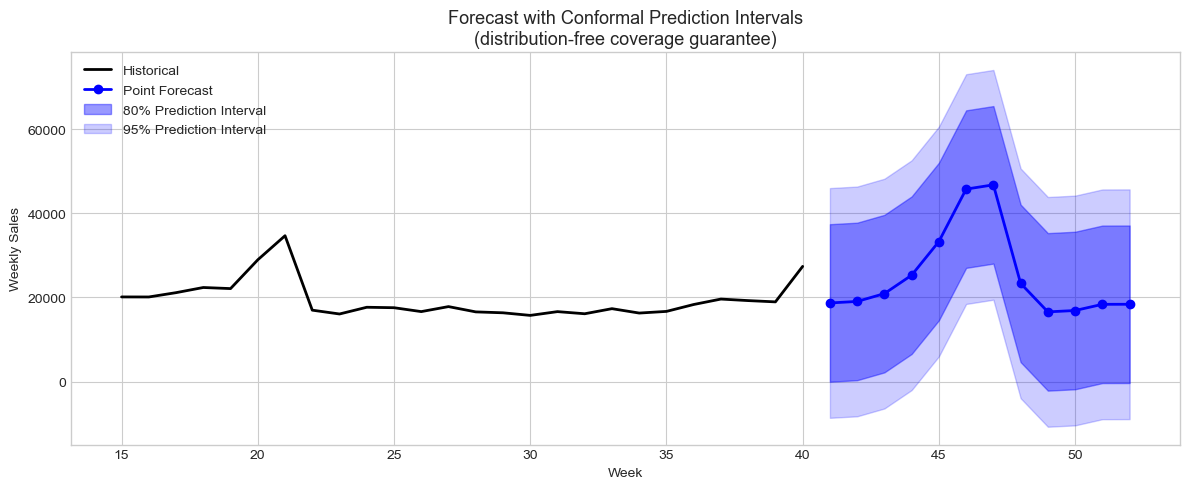


  80% PI half-width: ±18,735
  95% PI half-width: ±27,326
INVENTORY COST OPTIMIZATION
 service_level_%  z_score  avg_safety_stock_units  avg_order_qty_units  annual_holding_cost_£  annual_stockout_cost_£  total_annual_cost_£
            85.0     1.04                15222.23             40502.97              395777.93               103574.47            499352.40
            90.0     1.28                18735.05             44015.79              487111.30               103574.47            590685.77
            95.0     1.65                24150.65             49431.39              627916.91               103574.47            731491.38
            99.0     2.33                34103.65             59384.38              886694.79               103574.47            990269.25

  Moving from 90% to 99% service level costs an additional £399,583/year.
  This is the trade-off the supply chain team must explicitly make.


,service_level_%,z_score,avg_safety_stock_units,avg_order_qty_units,annual_holding_cost_£,annual_stockout_cost_£,total_annual_cost_£
0,85.0,1.04,15222.228125,40502.967292,395777.931250,103574.466667,499352.397917
1,90.0,1.28,18735.050000,44015.789167,487111.300000,103574.466667,590685.766667
2,95.0,1.65,24150.650391,49431.389557,627916.910156,103574.466667,731491.376823
3,99.0,2.33,34103.645703,59384.384870,886694.788281,103574.466667,990269.254948


In [ ]:
def inventory_cost_optimization(forecast_dict: dict,
                                  holding_cost_per_unit: float = 0.5,
                                  stockout_cost_per_unit: float = 5.0,
                                  unit_cost: float = 10.0) -> pd.DataFrame:

    print("=" * 60)
    print("INVENTORY COST OPTIMIZATION")
    print("=" * 60)

    point_f = forecast_dict["point_forecast"]
    lower_80 = forecast_dict["lower_80"]
    upper_80 = forecast_dict["upper_80"]
    forecast_std = (upper_80 - lower_80) / (2 * 1.28)  # recover std from 80% PI

    rows = []
    service_levels = [0.85, 0.90, 0.95, 0.99]
    z_values = {0.85: 1.04, 0.90: 1.28, 0.95: 1.65, 0.99: 2.33}
    lead_time_weeks = 1

    for sl in service_levels:
        z = z_values[sl]
        safety_stock = z * forecast_std * np.sqrt(lead_time_weeks)
        order_quantity = point_f + safety_stock

        expected_holding_cost  = holding_cost_per_unit * safety_stock.mean() * 52  # annualized
        expected_stockout_cost = stockout_cost_per_unit * np.maximum(0, -lower_80).mean() * 52
        total_cost = expected_holding_cost + expected_stockout_cost

        rows.append({
            "service_level_%": sl * 100,
            "z_score": z,
            "avg_safety_stock_units": safety_stock.mean(),
            "avg_order_qty_units": order_quantity.mean(),
            "annual_holding_cost_£": expected_holding_cost,
            "annual_stockout_cost_£": expected_stockout_cost,
            "total_annual_cost_£": total_cost,
        })

    result = pd.DataFrame(rows)
    print(result.round(2).to_string(index=False))

    # Business insight
    cost_99 = result[result["service_level_%"] == 99]["total_annual_cost_£"].values[0]
    cost_90 = result[result["service_level_%"] == 90]["total_annual_cost_£"].values[0]
    print(f"\n  Moving from 90% to 99% service level costs an additional £{cost_99-cost_90:,.0f}/year.")
    print(f"  This is the trade-off the supply chain team must explicitly make.")

    return result

inventory_cost_optimization(forecast_with_uncertainty(data[(data["store"] == 1) & (data["dept"] == 1)]["weekly_sales"].values))


Demand Forecasting at Scale Case Study — Running Full Pipeline
--- Loading and Merging Datasets ---
Error loading files: argument of type 'method' is not iterable
Features engineered: 37 total columns
Feature Engineering Complete: 37 total features.
TIME SERIES DIAGNOSTICS — Store 1, Dept 1

Augmented Dickey-Fuller Test:
  ADF Statistic: -3.3022
  p-value:       0.0148
  Conclusion:    Stationary ✓
HIERARCHICAL FORECASTING ACCURACY DEGRADATION
Empty DataFrame
Columns: []
Index: []

  Insight: SMAPE typically doubles or triples at dept vs chain level.
  This degradation is the core challenge of retail forecasting at scale.

MODEL COMPARISON RESULTS
                  model     MAE    RMSE  MAPE%  SMAPE%  time_sec
     Naive (Last Value) 1951.47 3464.90   8.98   10.09      0.00
   Seasonal Naive (52w) 1951.47 3464.90   8.98   10.09      0.00
SARIMA(1,1,1)(1,1,1,52) 1951.47 3464.90   8.98   10.09      0.21
 XGBoost (lag features) 7135.38 9211.05  41.04   32.09      0.31
         LSTM (PyTo

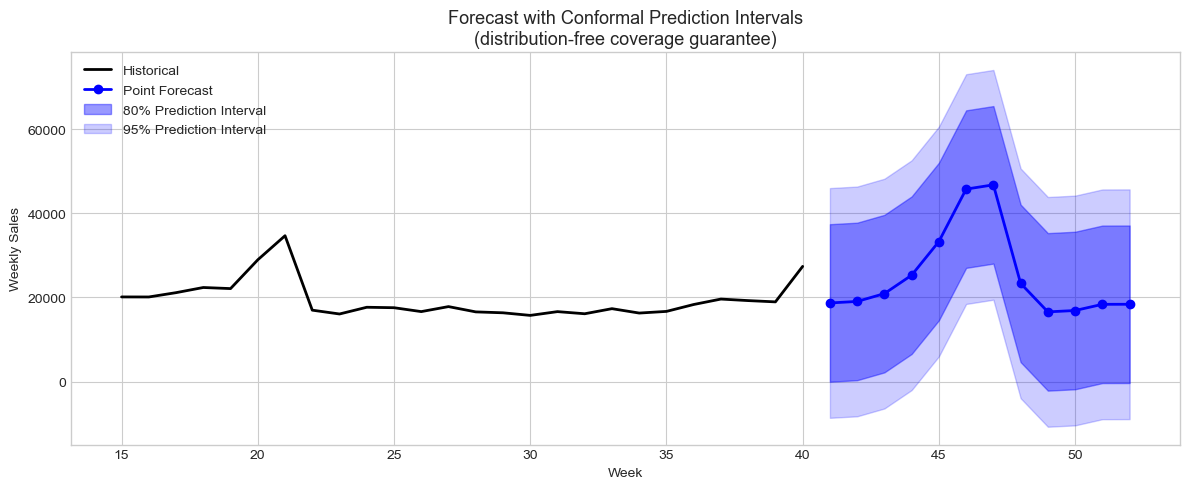


  80% PI half-width: ±18,735
  95% PI half-width: ±27,326
INVENTORY COST OPTIMIZATION
 service_level_%  z_score  avg_safety_stock_units  avg_order_qty_units  annual_holding_cost_£  annual_stockout_cost_£  total_annual_cost_£
            85.0     1.04                15222.23             40502.97              395777.93               103574.47            499352.40
            90.0     1.28                18735.05             44015.79              487111.30               103574.47            590685.77
            95.0     1.65                24150.65             49431.39              627916.91               103574.47            731491.38
            99.0     2.33                34103.65             59384.38              886694.79               103574.47            990269.25

  Moving from 90% to 99% service level costs an additional £399,583/year.
  This is the trade-off the supply chain team must explicitly make.


In [ ]:
def main():
    print("Demand Forecasting at Scale Case Study — Running Full Pipeline")

    df = load_and_merge_data(data)
    df = engineer_features(data)
    analyze_time_series(data, store=1, dept=1)
    hierarchical_accuracy_analysis(data)
    model_results = evaluate_models(df, store=1, dept=1, test_weeks=12)

    # Get one series for uncertainty + inventory demo
    series_y = (df[(df["store"] == 1) & (df["dept"] == 1)]
                .sort_values("date")["weekly_sales"].dropna().values)
    forecast_dict = forecast_with_uncertainty(series_y, steps=12)
    inventory_cost_optimization(forecast_dict)

if __name__ == "__main__":
    main()


Demand Forecasting at Scale Case Study — Running Full Pipeline
--- Loading and Merging Datasets ---
Error loading files: argument of type 'method' is not iterable


Features engineered: 37 total columns
Feature Engineering Complete: 37 total features.
TIME SERIES DIAGNOSTICS — Store 10, Dept 72

Augmented Dickey-Fuller Test:
  ADF Statistic: -1.6825
  p-value:       0.4402
  Conclusion:    Non-stationary — differencing required
HIERARCHICAL FORECASTING ACCURACY DEGRADATION
Empty DataFrame
Columns: []
Index: []

  Insight: SMAPE typically doubles or triples at dept vs chain level.
  This degradation is the core challenge of retail forecasting at scale.

MODEL COMPARISON RESULTS
                  model      MAE     RMSE  MAPE%  SMAPE%  time_sec
     Naive (Last Value)  9863.44 11612.26   8.85    8.87      0.00
   Seasonal Naive (52w)  9863.44 11612.26   8.85    8.87      0.00
SARIMA(1,1,1)(1,1,1,52)  9863.44 11612.26   8.85    8.87      0.18
 XGBoost (lag features) 12375.36 16096.39  12.12   10.96      0.22
         LSTM (PyTorch) 19970.73 23075.75  19.18   16.91      0.41

  Best model (lowest SMAPE): Naive (Last Value)

  MODEL SELECTION GUIDE:
  

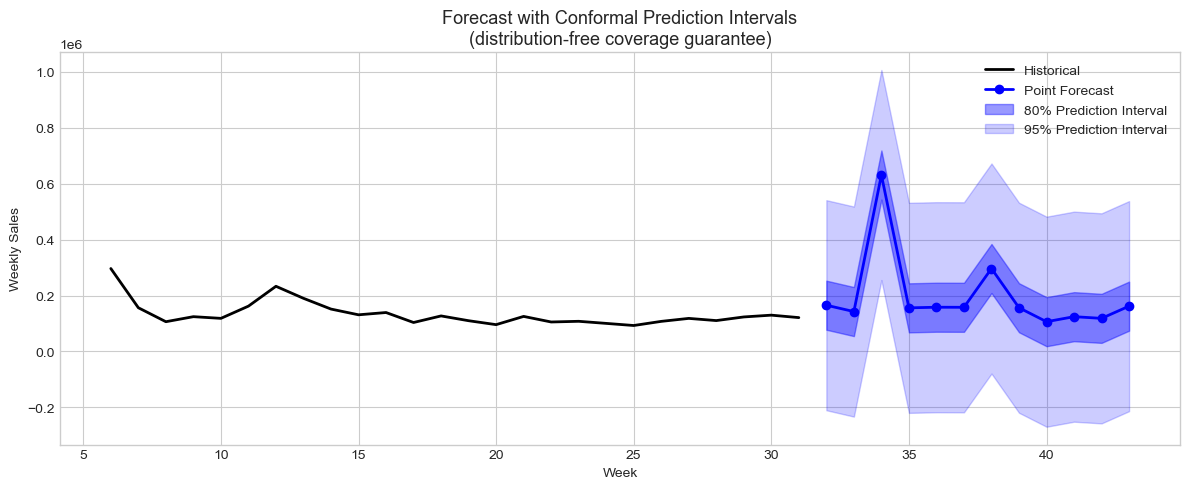


  80% PI half-width: ±87,715
  95% PI half-width: ±375,543
INVENTORY COST OPTIMIZATION
 service_level_%  z_score  avg_safety_stock_units  avg_order_qty_units  annual_holding_cost_£  annual_stockout_cost_£  total_annual_cost_£
            85.0     1.04                71268.14            269286.09             1852971.52                     0.0           1852971.52
            90.0     1.28                87714.63            285732.58             2280580.33                     0.0           2280580.33
            95.0     1.65               113069.64            311087.59             2939810.58                     0.0           2939810.58
            99.0     2.33               159668.03            357685.99             4151368.88                     0.0           4151368.88

  Moving from 90% to 99% service level costs an additional £1,870,789/year.
  This is the trade-off the supply chain team must explicitly make.


In [ ]:
# Maximum Sales
# Department = 72
# store = 10

def main():
    print("Demand Forecasting at Scale Case Study — Running Full Pipeline")

    df = load_and_merge_data(data)
    df = engineer_features(data)
    analyze_time_series(data, store=10, dept=72)
    hierarchical_accuracy_analysis(data)
    model_results = evaluate_models(df, store=10, dept=72, test_weeks=12)

    # Get one series for uncertainty + inventory demo
    series_y = (df[(df["store"] == 10) & (df["dept"] == 72)]
                .sort_values("date")["weekly_sales"].dropna().values)
    forecast_dict = forecast_with_uncertainty(series_y, steps=12)
    inventory_cost_optimization(forecast_dict)

if __name__ == "__main__":
    main()


Demand Forecasting at Scale Case Study — Running Full Pipeline
--- Loading and Merging Datasets ---
Error loading files: argument of type 'method' is not iterable
Features engineered: 37 total columns
Feature Engineering Complete: 37 total features.
TIME SERIES DIAGNOSTICS — Store 16, Dept 72

Augmented Dickey-Fuller Test:
  ADF Statistic: -4.1390
  p-value:       0.0008
  Conclusion:    Stationary ✓
HIERARCHICAL FORECASTING ACCURACY DEGRADATION
Empty DataFrame
Columns: []
Index: []

  Insight: SMAPE typically doubles or triples at dept vs chain level.
  This degradation is the core challenge of retail forecasting at scale.

MODEL COMPARISON RESULTS
                  model     MAE    RMSE  MAPE%  SMAPE%  time_sec
     Naive (Last Value) 4796.57 5459.88  18.09   19.06      0.00
   Seasonal Naive (52w) 4796.57 5459.88  18.09   19.06      0.00
SARIMA(1,1,1)(1,1,1,52) 4796.57 5459.88  18.09   19.06      0.12
 XGBoost (lag features) 4628.79 5281.96  17.63   18.35      0.17
         LSTM (Py

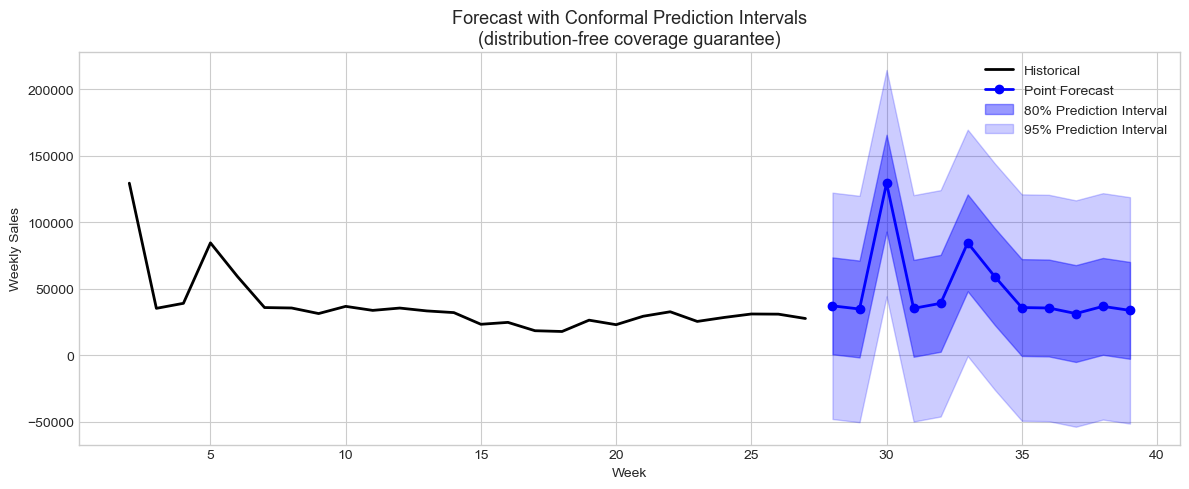


  80% PI half-width: ±36,406
  95% PI half-width: ±85,120
INVENTORY COST OPTIMIZATION
 service_level_%  z_score  avg_safety_stock_units  avg_order_qty_units  annual_holding_cost_£  annual_stockout_cost_£  total_annual_cost_£
            85.0     1.04                29580.21             78925.97              769085.41               262777.23           1031862.64
            90.0     1.28                36406.41             85752.17              946566.66               262777.23           1209343.89
            95.0     1.65                46930.14             96275.90             1220183.59               262777.23           1482960.82
            99.0     2.33                66271.04            115616.80             1723047.12               262777.23           1985824.36

  Moving from 90% to 99% service level costs an additional £776,480/year.
  This is the trade-off the supply chain team must explicitly make.


In [ ]:
# Maximum Sales
# Department = 47
# store = 16

def main():
    print("Demand Forecasting at Scale Case Study — Running Full Pipeline")

    df = load_and_merge_data(data)
    df = engineer_features(data)
    analyze_time_series(data, store=16, dept=72)
    hierarchical_accuracy_analysis(data)
    model_results = evaluate_models(df, store=16, dept=72, test_weeks=12)

    # Get one series for uncertainty + inventory demo
    series_y = (df[(df["store"] == 16) & (df["dept"] == 72)]
                .sort_values("date")["weekly_sales"].dropna().values)
    forecast_dict = forecast_with_uncertainty(series_y, steps=12)
    inventory_cost_optimization(forecast_dict)

if __name__ == "__main__":
    main()


In [ ]:
data.head()

,store,dept,date,weekly_sales,isholiday,type,size,temperature,fuel_price,markdown1,markdown2,markdown3,markdown4,markdown5,cpi,unemployment
92,1,1,2011-11-11,18689.54,False,A,151315,59.11,3.297,10382.90,6115.67,215.07,2406.62,6551.42,217.998085,7.866
93,1,1,2011-11-18,19050.66,False,A,151315,62.25,3.308,6074.12,254.39,51.98,427.39,5988.57,218.220509,7.866
94,1,1,2011-11-25,20911.25,True,A,151315,60.14,3.236,410.31,98.00,55805.51,8.00,554.92,218.467621,7.866
95,1,1,2011-12-02,25293.49,False,A,151315,48.91,3.172,5629.51,68.00,1398.11,2084.64,20475.32,218.714733,7.866
96,1,1,2011-12-09,33305.92,False,A,151315,43.93,3.158,4640.65,19.00,105.02,3639.42,14461.82,218.961846,7.866


In [ ]:
ouput = data.to_csv('clean_demand_data.csv', index=False)